# Lab 3

In [138]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import altair as alt

sns.set_theme(style="whitegrid", palette="muted")

In [3]:
df = pd.read_csv("data/music_streams.csv")

In [4]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [6]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='object')

In [9]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


## Histogram

### Monthly streams

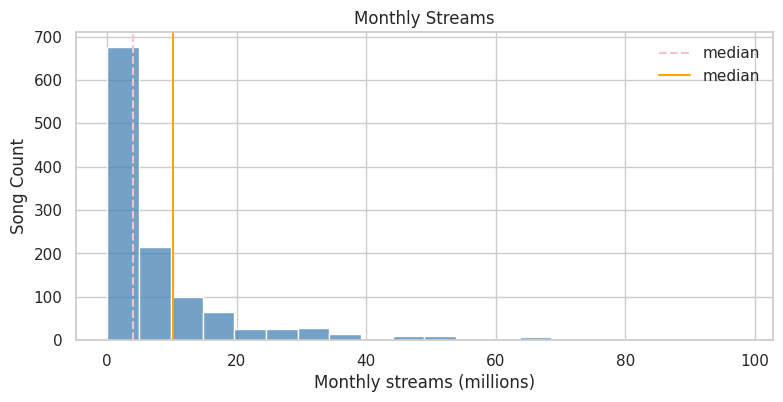

In [37]:
fig, ax= plt.subplots(figsize=(9, 4))
median = df.streams_millions.median()
mean = df.streams_millions.mean()
sns.histplot(data=df [df.streams_millions < 100], x="streams_millions", bins=20, color="steelblue")
ax.axvline(median, color="pink", linestyle="--", label="median")
ax.axvline(mean, color="orange", label="median")
ax.legend(frameon=False)
ax.set_xlabel("Monthly streams (millions)")
ax.set_ylabel("Song Count")
ax.set_title("Monthly Streams")
plt.show()

### Monthly Listeners

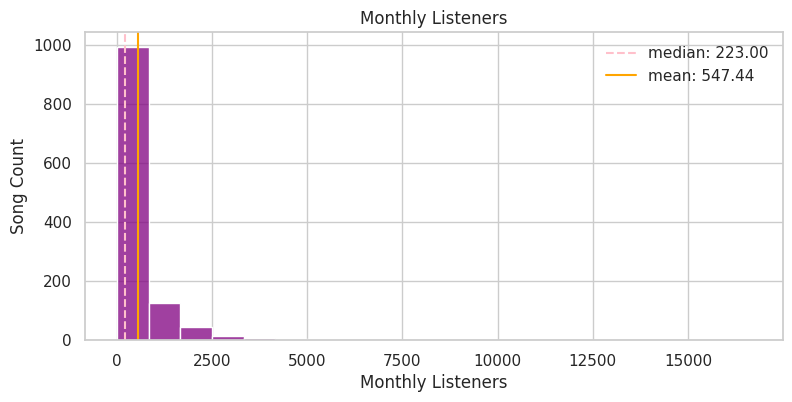

In [40]:
fig, ax= plt.subplots(figsize=(9, 4))
median = df.monthly_listeners.median()
mean = df.monthly_listeners.mean()
sns.histplot(data=df, x="monthly_listeners", bins=20, color="purple")
ax.axvline(median, color="pink", linestyle="--", label=f"median: {median:.2f}")
ax.axvline(mean, color="orange", label=f"mean: {mean:.2f}")
ax.legend(frameon=False)
ax.set_xlabel("Monthly Listeners")
ax.set_ylabel("Song Count")
ax.set_title("Monthly Listeners")
plt.show()

## Boxplots

In [50]:
order = df.groupby("genre")["energy"].median().sort_values(ascending=False).index
order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

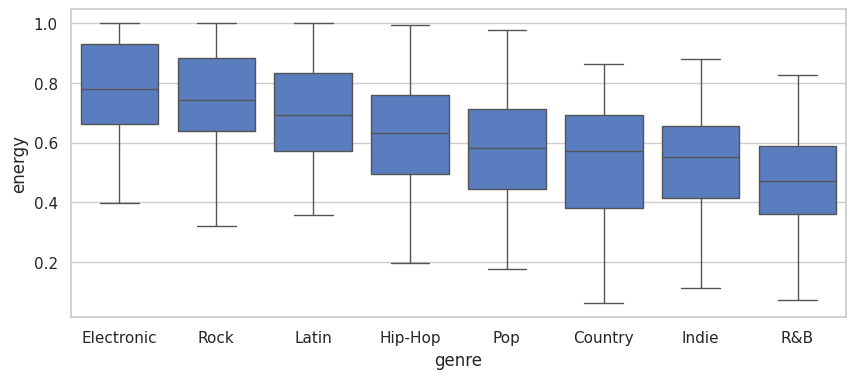

In [47]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x="genre", y="energy", order=order, ax=ax)


### Boxplot 2

In [56]:
order2 = df.groupby("genre")["loudness_db"].median().sort_values(ascending=False).index
order2

Index(['Country', 'Latin', 'Electronic', 'Pop', 'R&B', 'Hip-Hop', 'Rock',
       'Indie'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='loudness_db'>

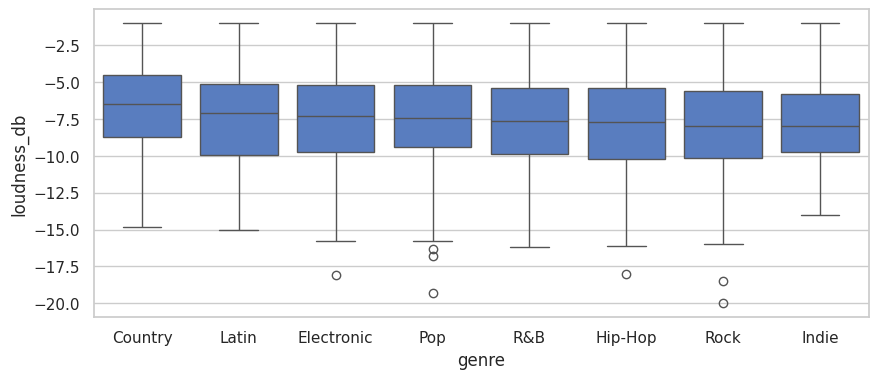

In [59]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x="genre", y="loudness_db", order=order2, ax=ax)

### Boxplot 3

In [62]:
order3 = df.groupby("genre")["playlist_adds"].median().sort_values(ascending=False).index
order3

Index(['Electronic', 'Hip-Hop', 'Latin', 'Pop', 'Indie', 'Country', 'Rock',
       'R&B'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='playlist_adds'>

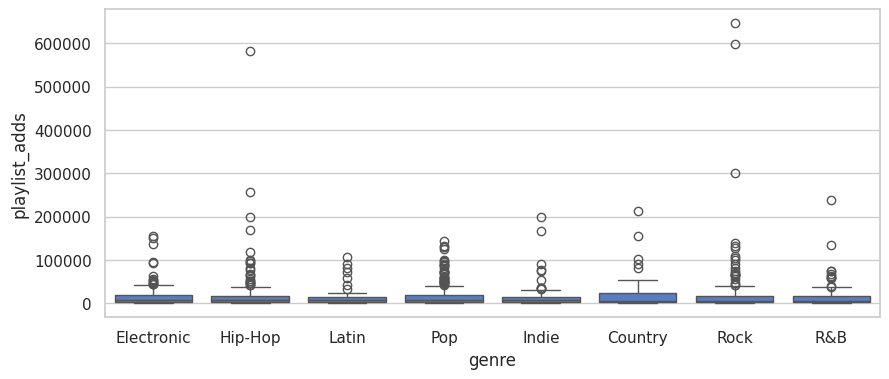

In [63]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x="genre", y="playlist_adds", order=order3, ax=ax)

## Scatterplot

### Scatterplot 1

<Axes: xlabel='energy', ylabel='danceability'>

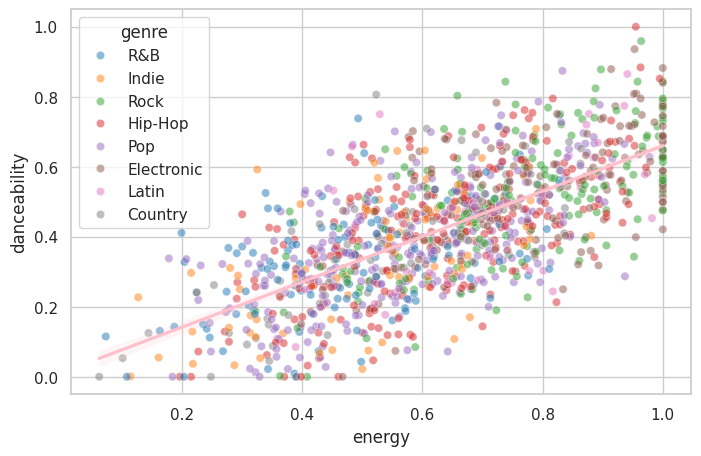

In [76]:
sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="energy", y="danceability", hue="genre", color="darkgrey", alpha=0.5, palette="tab10")
sns.regplot(data=df, x="energy", y="danceability", scatter=False, color="pink")

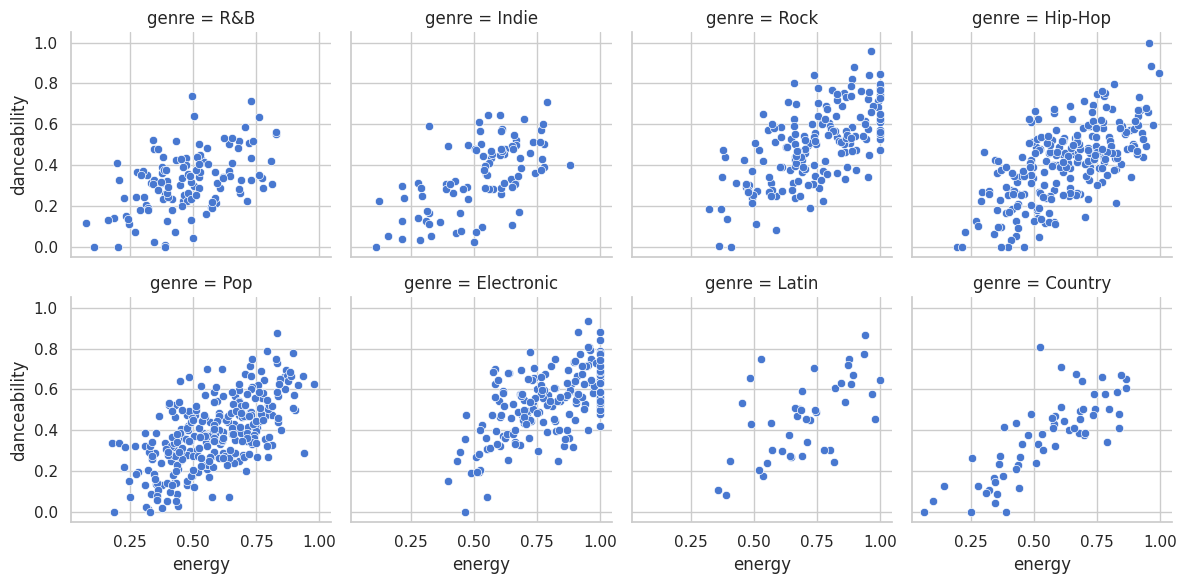

In [79]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability")

### Scatterplot 2

<Axes: xlabel='energy', ylabel='loudness_db'>

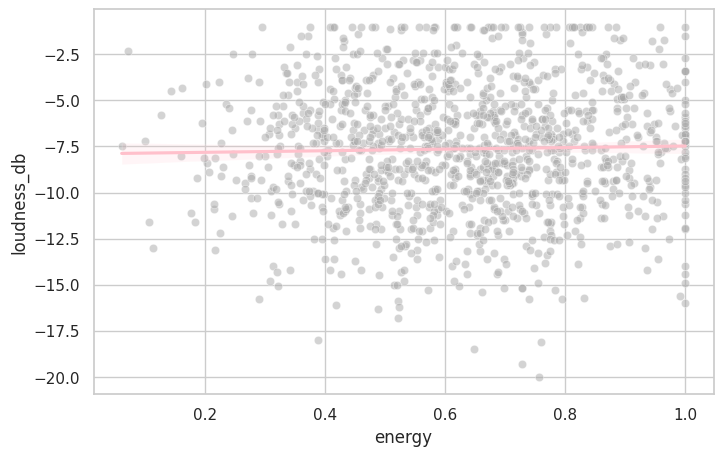

In [85]:
sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="energy", y="loudness_db", color="darkgrey", alpha=0.5)
sns.regplot(data=df, x="energy", y="loudness_db", scatter=False, color="pink")

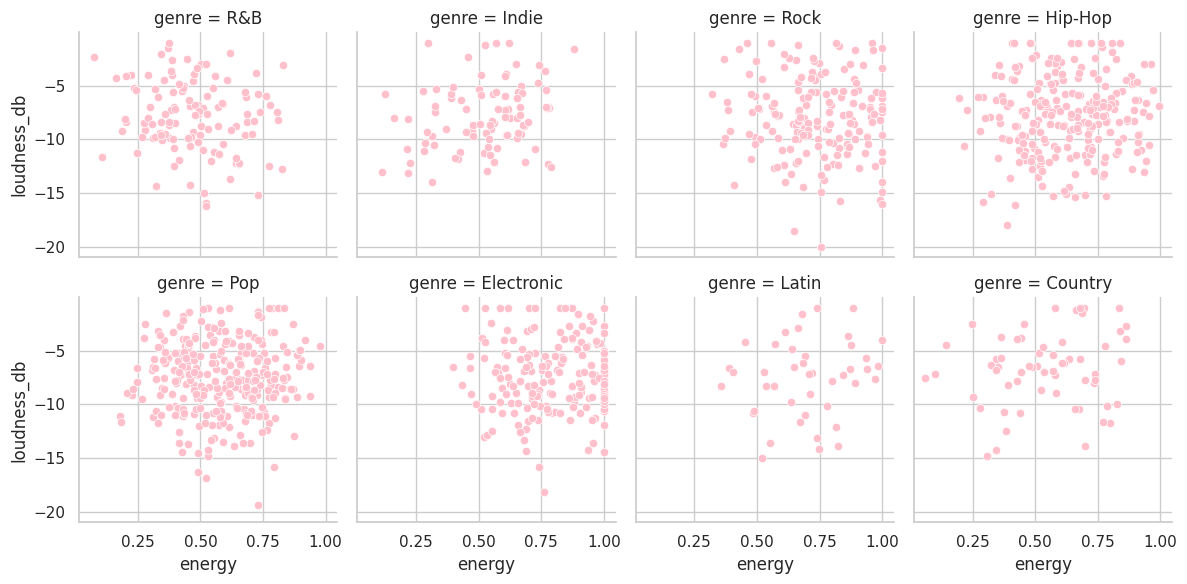

In [84]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "loudness_db", color="pink")

## Line Charts and Friends

### Line Chart 1

In [86]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [87]:
df.year.unique()

array([2024, 2020, 2017, 2022, 2015, 2023, 2021, 2019, 2018, 2016])

In [90]:
pop_trend = df[df["genre"] == "Pop"].groupby("year")["streams_millions"].median()
pop_trend

,streams_millions
year,
2015,7.160
2016,3.540
2017,3.560
2018,11.370
2019,4.720
2020,5.075
2021,3.645
2022,4.445
2023,4.230


    year       genre  streams_millions
0   2015  Electronic             6.040
1   2015     Hip-Hop             5.755
2   2015         Pop             7.160
3   2015         R&B             3.590
4   2015        Rock             4.800
5   2016  Electronic             5.520
6   2016     Hip-Hop             5.650
7   2016         Pop             3.540
8   2016         R&B             5.840
9   2016        Rock             5.390
10  2017  Electronic             4.120
11  2017     Hip-Hop             4.660
12  2017         Pop             3.560
13  2017         R&B             3.910
14  2017        Rock             5.150
15  2018  Electronic             4.180
16  2018     Hip-Hop             4.590
17  2018         Pop            11.370
18  2018         R&B             5.520
19  2018        Rock             3.060
20  2019  Electronic             2.900
21  2019     Hip-Hop             3.080
22  2019         Pop             4.720
23  2019         R&B             5.080
24  2019        Rock     

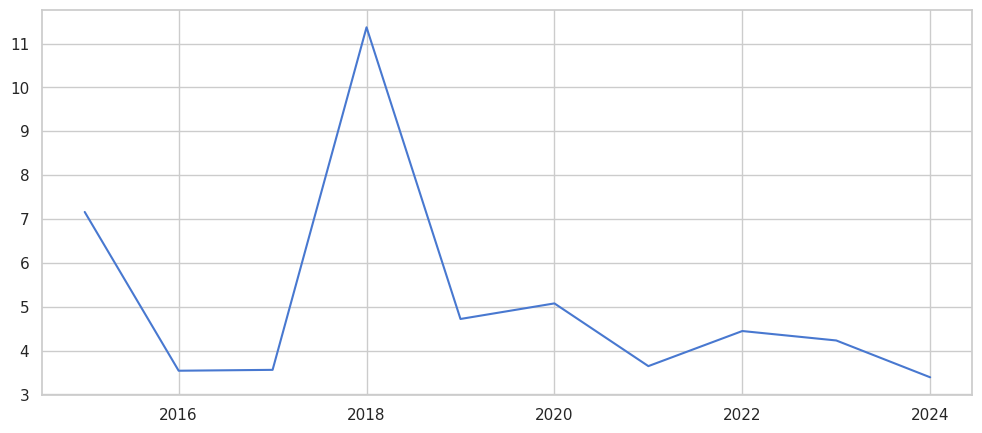

In [98]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pop_trend.index, pop_trend)

In [99]:
df.genre.unique()

array(['R&B', 'Indie', 'Rock', 'Hip-Hop', 'Pop', 'Electronic', 'Latin',
       'Country'], dtype=object)

In [114]:
# ignore

[i for i in zip(axes, genre)]

[(<Axes: title={'center': 'Pop'}>, 'I'),
 (<Axes: title={'center': 'Hip-Hop'}>, 'n'),
 (<Axes: title={'center': 'R&B'}>, 'd'),
 (<Axes: title={'center': 'Rock'}>, 'i'),
 (<Axes: title={'center': 'Electronic'}>, 'e')]

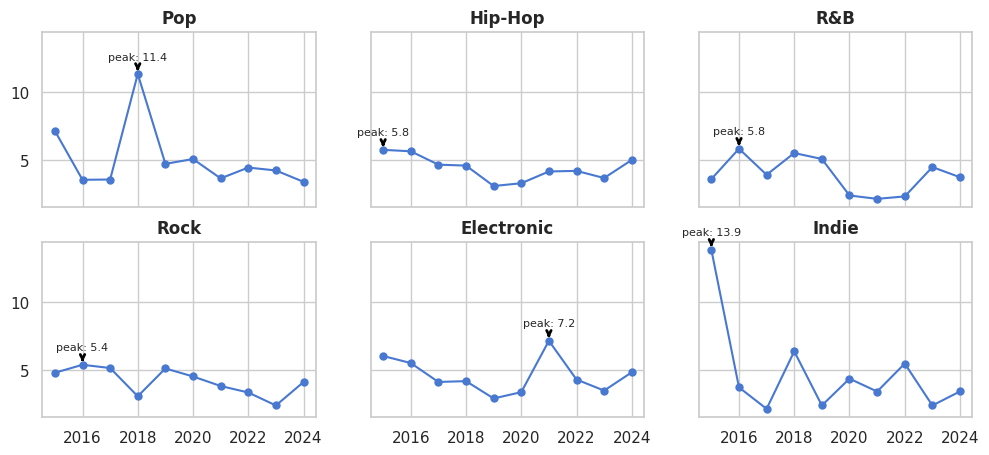

In [125]:
genres = ["Pop", "Hip-Hop", "R&B", "Rock", "Electronic", "Indie"]

trend = df[df["genre"].isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

# print(trend)

# sharex to prevent overlap between title and x-axis and get graphs to share same x-axis

# sharey to get graphs to share same y-axis

fig, axes = plt.subplots(2,3,figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    peak = subD.loc[subD.streams_millions.idxmax()]
    ax.annotate(f"peak: {peak.streams_millions:.1f}", xy=(peak.year, peak.streams_millions), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=8, arrowprops=dict(arrowstyle="->", color="black", lw=2))
    ax.plot(subD.year, subD.streams_millions, marker="o", ms=5)
    ax.set_title(genre, fontweight="bold")

### Line Chart 2

In [126]:
df.genre.unique()

array(['R&B', 'Indie', 'Rock', 'Hip-Hop', 'Pop', 'Electronic', 'Latin',
       'Country'], dtype=object)

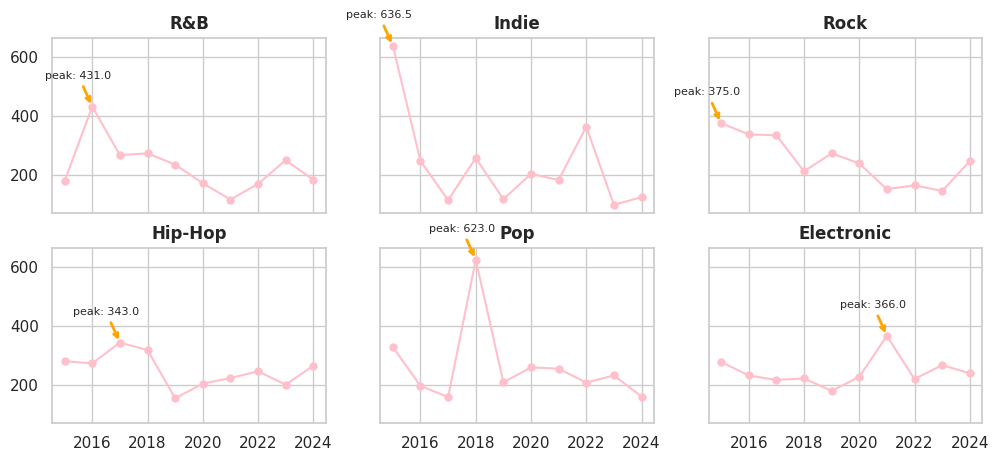

In [132]:
genres = ['R&B', 'Indie', 'Rock', 'Hip-Hop', 'Pop', 'Electronic', 'Latin', 'Country']

trend = df[df["genre"].isin(genres)].groupby(["year", "genre"])["monthly_listeners"].median().reset_index()

fig, axes = plt.subplots(2,3,figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    peak = subD.loc[subD.monthly_listeners.idxmax()]
    ax.annotate(f"peak: {peak.monthly_listeners:.1f}", xy=(peak.year, peak.monthly_listeners), xytext=(-10, 20), textcoords="offset points", ha="center", fontsize=8, arrowprops=dict(arrowstyle="->", color="orange", lw=2))
    ax.plot(subD.year, subD.monthly_listeners, marker="o", ms=5, color="pink")
    ax.set_title(genre, fontweight="bold")

## Vegalite (Area Chart)

## Year and Streams using Altair

In [141]:
alt.Chart(df).mark_area(color="pink").encode(x=alt.X("year:O", title="Year"),y=alt.Y("sum(streams_millions):Q",title="Total Streams (Millions)")).properties(title="Total Streams by Year", width=800)

alt.Chart(...)

In [149]:
genres = ['R&B', 'Indie', 'Rock', 'Hip-Hop', 'Pop', 'Electronic', 'Latin', 'Country']

trend = (df[df["genre"].isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index())

alt.Chart(trend).mark_area(color="pink",opacity=0.7).encode(x=alt.X("year:O", title="Year"),y=alt.Y("streams_millions:Q",title="Streams (Millions)")).facet(facet=alt.Facet("genre:N", title="Streams (Millions) by Genre"),columns=4)

alt.FacetChart(...)